# Stage 2 — Faithfulness Results

Analyses accuracy across two datasets under faithfulness-negative steering (suppressing confabulation-preferred experts):
- **faith_cf**: FaithEval-Counterfactual — MCQ where context contradicts training knowledge. Faithful model follows context.
- **faith_race**: RACE reading comprehension control — context and knowledge agree. Should be unaffected by steering.

Conditions: `baseline` / `hard` / `soft`

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display as ipy_display
import pandas as pd

sns.set_theme(style='whitegrid', font='serif')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
})

RESULTS_DIR = os.environ.get(
    'RESULTS_DIR',
    os.path.join(os.path.expanduser('~'), 'projects/Individual-Project-25-26/stage2/results')
)
OUT_DIR = 'figures'
os.makedirs(OUT_DIR, exist_ok=True)

def load(task, condition):
    path = os.path.join(RESULTS_DIR, task, f'{condition}.json')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

task_keys = ['faith_cf', 'faith_race']
conditions = ['baseline', 'hard', 'soft']
data = {t: {c: load(t, c) for c in conditions} for t in task_keys}

for t in task_keys:
    for c in conditions:
        d = data[t][c]
        if d:
            print(f'{t}/{c}: accuracy={d["accuracy"]:.3f}  n={d["n_complete"]}')
        else:
            print(f'{t}/{c}: not found')

faith_cf/baseline: accuracy=0.728  n=500
faith_cf/hard: accuracy=0.734  n=500
faith_cf/soft: accuracy=0.766  n=500
faith_race/baseline: accuracy=0.792  n=500
faith_race/hard: accuracy=0.802  n=500
faith_race/soft: accuracy=0.762  n=500


## 1. Accuracy: Baseline vs Hard vs Soft

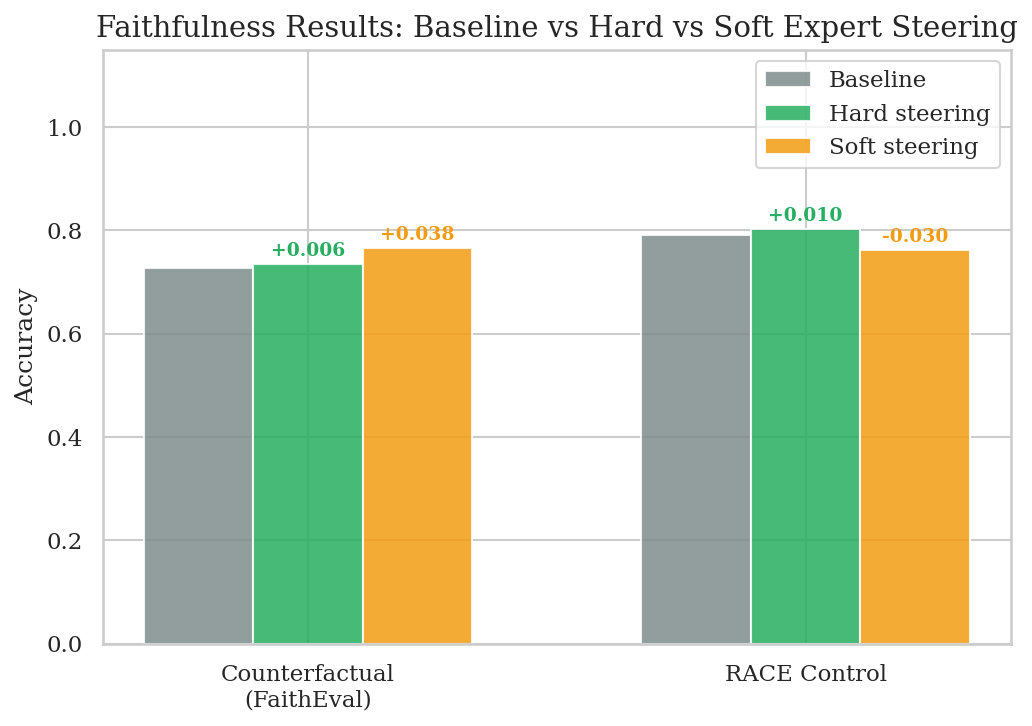

In [2]:
labels = [
    'Counterfactual\n(FaithEval)',
    'RACE Control',
]

def acc(task, cond):
    d = data[task][cond]
    return d['accuracy'] if d else float('nan')

baselines = [acc(t, 'baseline') for t in task_keys]
hards     = [acc(t, 'hard')     for t in task_keys]
softs     = [acc(t, 'soft')     for t in task_keys]

x = np.arange(len(labels))
w = 0.22

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - w, baselines, width=w, label='Baseline',      color='#7f8c8d', alpha=0.85)
ax.bar(x,     hards,     width=w, label='Hard steering', color='#27ae60', alpha=0.85)
ax.bar(x + w, softs,     width=w, label='Soft steering', color='#f39c12', alpha=0.85)

for i, (b, h, s) in enumerate(zip(baselines, hards, softs)):
    for val, xpos, color in [(h, x[i], '#27ae60'), (s, x[i] + w, '#f39c12')]:
        if not (np.isnan(b) or np.isnan(val)):
            ax.annotate(f'{val - b:+.3f}', xy=(xpos, val), xytext=(0, 4),
                        textcoords='offset points', ha='center', fontsize=9,
                        color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.15)
ax.set_title('Faithfulness Results: Baseline vs Hard vs Soft Expert Steering')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'faithfulness_results.png'), dpi=300, bbox_inches='tight')
plt.show()

## 2. Numerical Summary

In [3]:
print(f"{'Dataset':30s} {'Baseline':>10} {'Hard':>10} {'Delta Hard':>10} {'Soft':>10} {'Delta Soft':>10}")
print('-' * 80)
for label, task in zip(labels, task_keys):
    b = acc(task, 'baseline')
    h = acc(task, 'hard')
    s = acc(task, 'soft')
    dh = h - b if not (np.isnan(b) or np.isnan(h)) else float('nan')
    ds = s - b if not (np.isnan(b) or np.isnan(s)) else float('nan')
    print(f"{label.replace(chr(10), ' '):30s} {b:10.3f} {h:10.3f} {dh:+10.3f} {s:10.3f} {ds:+10.3f}")

Dataset                          Baseline       Hard Delta Hard       Soft Delta Soft
--------------------------------------------------------------------------------
Counterfactual (FaithEval)          0.728      0.734     +0.006      0.766     +0.038
RACE Control                        0.792      0.802     +0.010      0.762     -0.030


## 3. Mismatch Inspection

Records where the steered condition flips the correctness label relative to baseline.

In [4]:
def _esc(text):
    return str(text).replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')

def _badge(correct):
    if correct:
        return '<span style="background:#27ae60;color:#fff;padding:2px 8px;border-radius:3px;font-weight:700;font-size:12px">CORRECT</span>'
    return '<span style="background:#c0392b;color:#fff;padding:2px 8px;border-radius:3px;font-weight:700;font-size:12px">WRONG</span>'

def _box(text, bg='#f8f9fa'):
    return (f'<div style="background:{bg};border:1px solid #dee2e6;border-radius:4px;'
            f'padding:10px;max-height:180px;overflow-y:auto;white-space:pre-wrap;'
            f'font-family:monospace;font-size:12px;line-height:1.45;color:#111">'
            f'{_esc(text)}</div>')

rows = []
for task in task_keys:
    for cond in ['hard', 'soft']:
        d = data[task][cond]
        if d:
            rows.append({'task': task, 'cond': cond,
                         'n_mismatches': d.get('n_mismatches', 0),
                         'n_total': d['n_complete']})
df = pd.DataFrame(rows)
if not df.empty:
    df['pct'] = (df['n_mismatches'] / df['n_total'] * 100).round(1)
    display(df)

baseline_lookup = {}
for task in task_keys:
    d = data[task].get('baseline')
    if d:
        baseline_lookup[task] = {r['idx']: r for r in d['records']}

def render_mismatches(task, cond):
    d = data[task][cond]
    if not d:
        print(f'No data for {task}/{cond}')
        return
    mismatches = [r for r in d['records'] if r.get('mismatch')]
    if not mismatches:
        ipy_display(HTML(f'<p><em>No mismatches for {task} / {cond}.</em></p>'))
        return
    parts = [f'<div style="font-family:Arial,sans-serif;color:#111"><h3>{task} &rarr; {cond} ({len(mismatches)} mismatches)</h3>']
    for r in mismatches:
        arrow = f"{_badge(r['baseline_correct'])} &rarr; {_badge(r['correct'])}"
        gold = _esc(r.get('gold', '?'))
        pred = _esc(r.get('prediction', r.get('response', '?'))[:80])
        parts.append(
            f'<div style="border:1px solid #bdc3c7;border-radius:6px;margin:12px 0;padding:14px;background:#fff">'
            f'<div style="margin-bottom:8px"><b>idx {r["idx"]}</b> &nbsp; {arrow} &nbsp; gold: <code>{gold}</code> &nbsp; pred: <code>{pred}</code></div>'
            f'<div style="margin-bottom:10px"><b>PROMPT</b>'
            f'<div style="background:#eaf0fb;border-left:3px solid #27ae60;padding:8px 10px;margin-top:4px;'
            f'white-space:pre-wrap;font-family:monospace;font-size:11px;color:#111;max-height:120px;overflow-y:auto">{_esc(r["prompt"])}</div></div>'
            f'<div style="display:grid;grid-template-columns:1fr 1fr;gap:12px">'
            f'<div><b>BASELINE response</b>{_box(baseline_lookup.get(task, {}).get(r["idx"], {}).get("response", "(not found)"), "#fdfefe")}</div>'
            f'<div><b>{cond.upper()} response</b>{_box(r["response"], "#fef9e7")}</div>'
            f'</div></div>'
        )
    parts.append('</div>')
    ipy_display(HTML(''.join(parts)))

,task,cond,n_mismatches,n_total,pct
0,faith_cf,hard,19,500,3.8
1,faith_cf,soft,63,500,12.6
2,faith_race,hard,15,500,3.0
3,faith_race,soft,39,500,7.8


In [5]:
for task in task_keys:
    for cond in ['hard', 'soft']:
        render_mismatches(task, cond)

## Discussion

*(Fill in after examining results.)*

**Counterfactual**: increase in accuracy = model following context more faithfully after suppressing confabulation experts.

**RACE control**: should remain flat. A large drop indicates steering degrades general reading comprehension — a sign the intervention is too crude.

**Key question**: does faithfulness improve on FaithEval-CF without degrading RACE accuracy?